In [19]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT / "src"))
from conformal.methods.global_cp import run_global_conformal
from conformal.metrics import compare_results
from conformal.plots import plot_interval_grid
from conformal.metrics import *
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = PROJECT_ROOT / "outputs" / "base_model"
processed_dir = PROJECT_ROOT / "outputs" / "conformal" / "processed_results"
unprocessed_dir = PROJECT_ROOT / "outputs" / "conformal" / "unprocessed_results"

alpha = 0.10
y_true_col = "y_true_kelvin"
y_pred_col = "y_pred_kelvin"

cal_files = {
    1: base_dir / "Calibration_long_1.csv",
    2: base_dir / "Calibration_long_2.csv",
    3: base_dir / "Calibration_long_3.csv",
    4: base_dir / "Calibration_long_4.csv",
}

test_files = {
    1: base_dir / "Test_long_1.csv",
    2: base_dir / "Test_long_2.csv",
    3: base_dir / "Test_long_3.csv",
    4: base_dir / "Test_long_4.csv",}

unprocesssed_files = {
    "Global": unprocessed_dir / "dynamic_unprocessed_results.csv",
    "Stratified": unprocessed_dir / "global_unprocessed_results.csv",
    "Weighted+Shrinkage": unprocessed_dir / "stratified_unprocessed_results.csv",
    "Dynamic Graph": unprocessed_dir / "weighted_unprocessed_results.csv",
    "Global Clim Mix Convex": unprocessed_dir / "global_clim_mix_predictions_convex.csv",
   "Global Clim Mix Infl": unprocessed_dir / "global_clim_mix_predictions_inflation_only.csv"
}

processsed_files = {
    "Global": processed_dir / "dynamic_summary.csv",
    "Stratified": processed_dir / "global_summary.csv",
    "Weighted+Shrinkage": processed_dir / "stratified_summary.csv",
    "Dynamic Graph": processed_dir / "weighted_summary.csv"
}


In [16]:
test = pd.read_csv(unprocesssed_files["Global"])
test.head()

,horizon,Region,y_true,y_pred,lower,upper,covered,width,interval_score,forecast_date,reference_date,q_hat,Season,method
0,1,W,268.648148,272.970039,268.106944,277.833133,True,9.726189,9.726189,202107,202106,4.863095,Winter,dynamic_graph
1,1,W,273.754786,273.721282,268.332505,279.110059,True,10.777555,10.777555,202108,202107,5.388777,Winter,dynamic_graph
2,1,W,274.978508,275.844345,271.920892,279.767798,True,7.846905,7.846905,202109,202108,3.923453,Winter,dynamic_graph
3,1,W,277.162459,276.045570,272.572717,279.518423,True,6.945706,6.945706,202110,202109,3.472853,Winter,dynamic_graph
4,1,W,276.235142,277.690428,274.243407,281.137449,True,6.894042,6.894042,202111,202110,3.447021,Spring,dynamic_graph


In [10]:
summary_by_method = {}

for method, path in unprocesssed_files.items():
    df = pd.read_csv(path)

    summary = (
        df.groupby(["Region", "horizon"], observed=False)
          .agg(
              coverage=("covered", "mean"),
              interval_score=("interval_score", "mean"),
          )
          .reset_index()
    )

    summary_by_method[method] = summary

In [11]:
list(summary_by_method.keys())

['Global',
 'Stratified',
 'Weighted+Shrinkage',
 'Dynamic Graph',
 'Global Clim Mix Convex',
 'Global Clim Mix Infl']

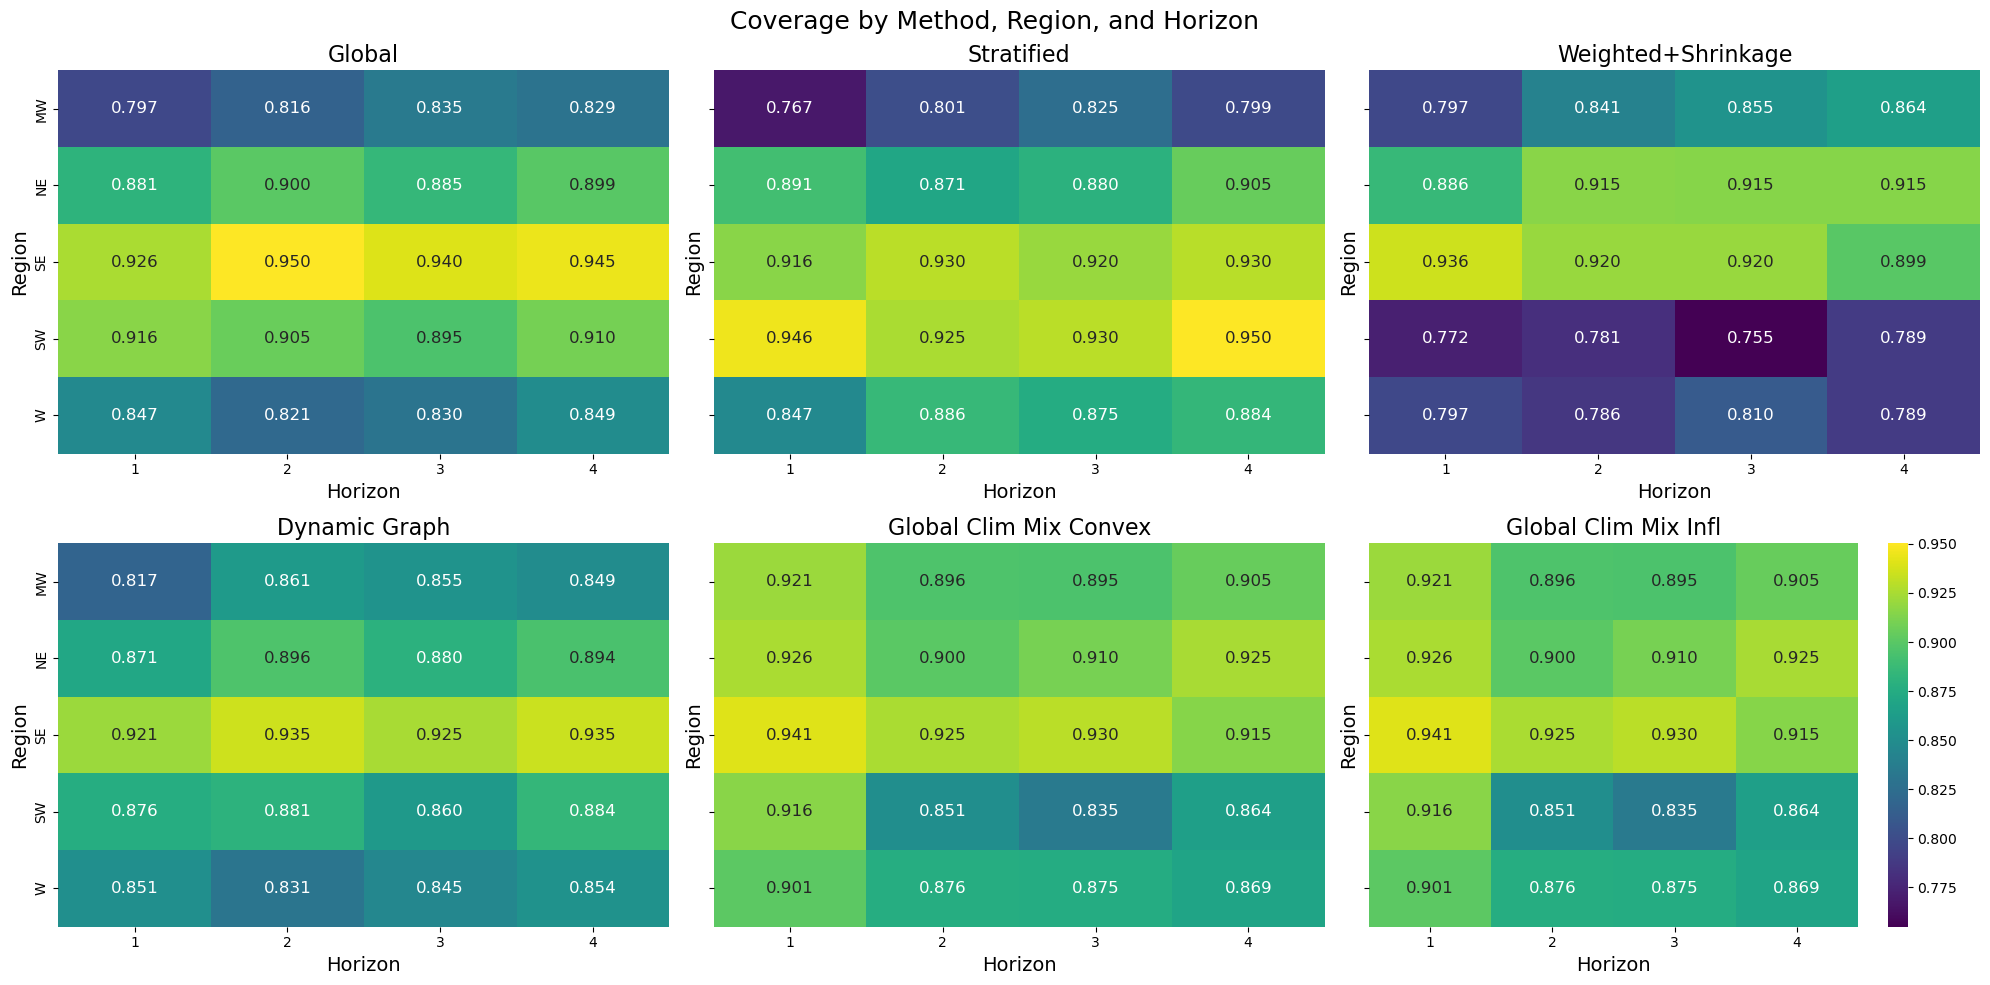

In [13]:

methods = list(summary_by_method.keys())

fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharey=True)

# global color scale (important!)
all_cov = pd.concat(summary_by_method.values())["coverage"]
vmin, vmax = all_cov.min(), all_cov.max()

for ax, method in zip(axes.flatten(), methods):
    df = summary_by_method[method]

    heat = df.pivot(index="Region", columns="horizon", values="coverage")

    sns.heatmap(
        heat,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        annot_kws={"size": 12},
        ax=ax,
        cbar=(method == methods[-1])
    )

    ax.set_title(method, fontsize=16)
    ax.set_xlabel("Horizon", fontsize=14)
    ax.set_ylabel("Region", fontsize=14)

fig.suptitle("Coverage by Method, Region, and Horizon", fontsize=18)
plt.tight_layout()
plt.show()

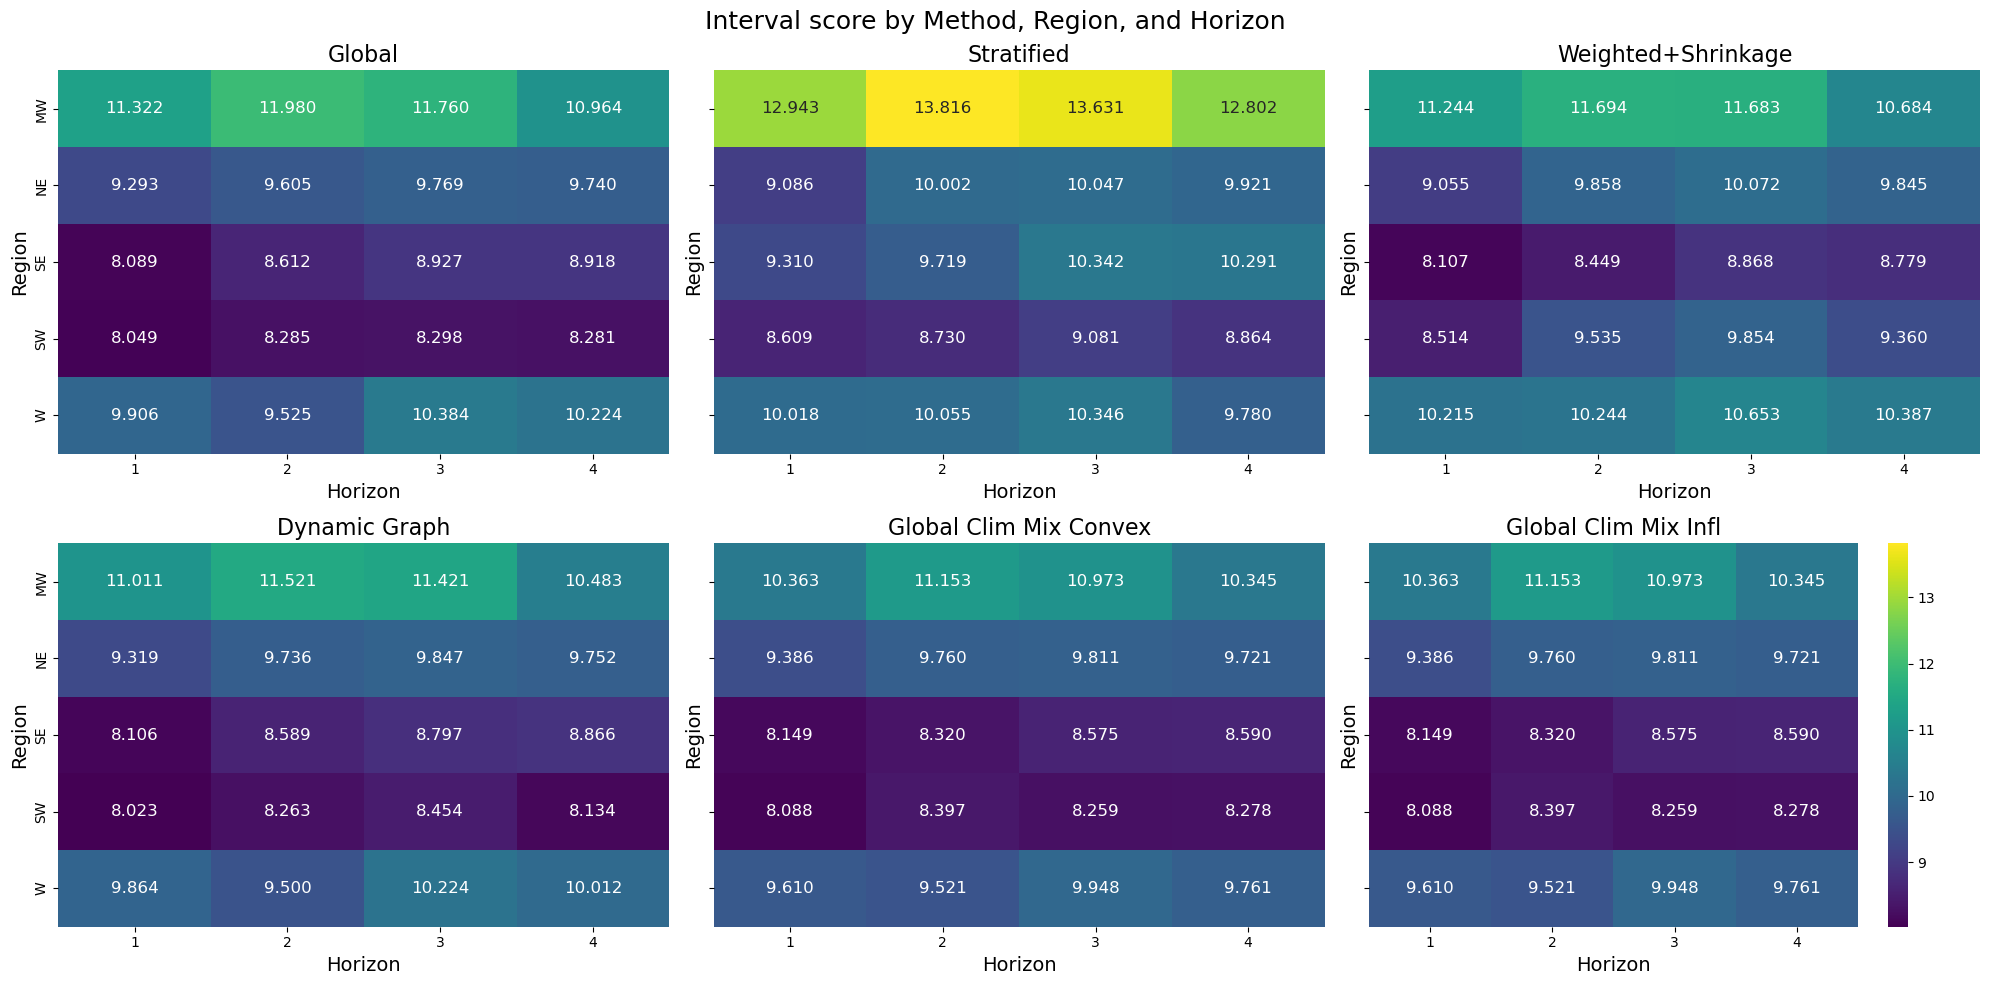

In [15]:
methods = list(summary_by_method.keys())

fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharey=True)

# global color scale (important!)
all_cov = pd.concat(summary_by_method.values())["interval_score"]
vmin, vmax = all_cov.min(), all_cov.max()

for ax, method in zip(axes.flatten(), methods):
    df = summary_by_method[method]

    heat = df.pivot(index="Region", columns="horizon", values="interval_score")

    sns.heatmap(
        heat,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        annot_kws={"size": 12},
        ax=ax,
        cbar=(method == methods[-1])
    )

    ax.set_title(method, fontsize=16)
    ax.set_xlabel("Horizon", fontsize=14)
    ax.set_ylabel("Region", fontsize=14)

fig.suptitle("Interval score by Method, Region, and Horizon", fontsize=18)
plt.tight_layout()
plt.show()

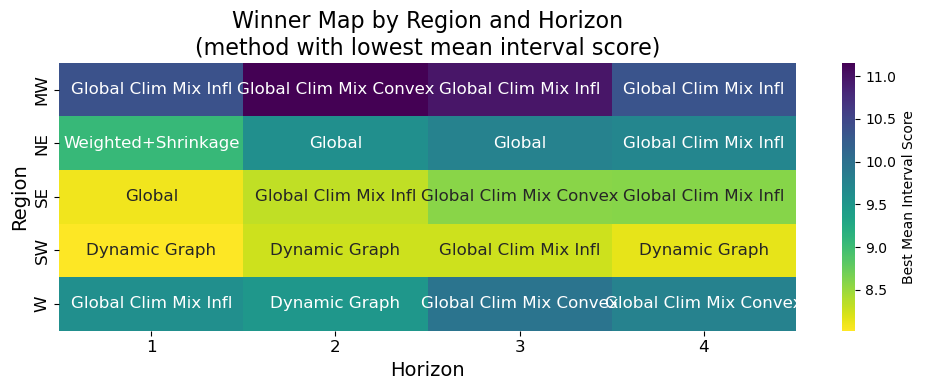

In [18]:
# ---------------------------------
# summarize each method
# ---------------------------------
summary_rows = []

for method, path in unprocesssed_files.items():
    df = pd.read_csv(path)

    tmp = (
        df.groupby(["Region", "horizon"], observed=False)
          .agg(
              coverage=("covered", "mean"),
              interval_score=("interval_score", "mean"),
              median_width=("upper", lambda x: np.nan)  # placeholder
          )
          .reset_index()
    )

    # median width separately
    width_tmp = (
        df.assign(width=df["upper"] - df["lower"])
          .groupby(["Region", "horizon"], observed=False)["width"]
          .median()
          .reset_index()
          .rename(columns={"width": "median_width"})
    )

    tmp = tmp.drop(columns="median_width").merge(width_tmp, on=["Region", "horizon"])
    tmp["Method"] = method
    summary_rows.append(tmp)

summary_df = pd.concat(summary_rows, ignore_index=True)

# ---------------------------------
# winner by interval score
# ---------------------------------
winner_df = (
    summary_df.sort_values("interval_score")
              .groupby(["Region", "horizon"], as_index=False)
              .first()
)

# Pivot to method names for annotation
winner_map = winner_df.pivot(index="Region", columns="horizon", values="Method")

# Also pivot best interval score for coloring
winner_score_map = winner_df.pivot(index="Region", columns="horizon", values="interval_score")

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    winner_score_map,
    annot=winner_map,
    fmt="",
    cmap="viridis_r",   # lower interval score = better
    cbar_kws={"label": "Best Mean Interval Score"},
    annot_kws={"size": 12}
)

ax.set_title("Winner Map by Region and Horizon\n(method with lowest mean interval score)", fontsize=16)
ax.set_xlabel("Horizon", fontsize=14)
ax.set_ylabel("Region", fontsize=14)
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()

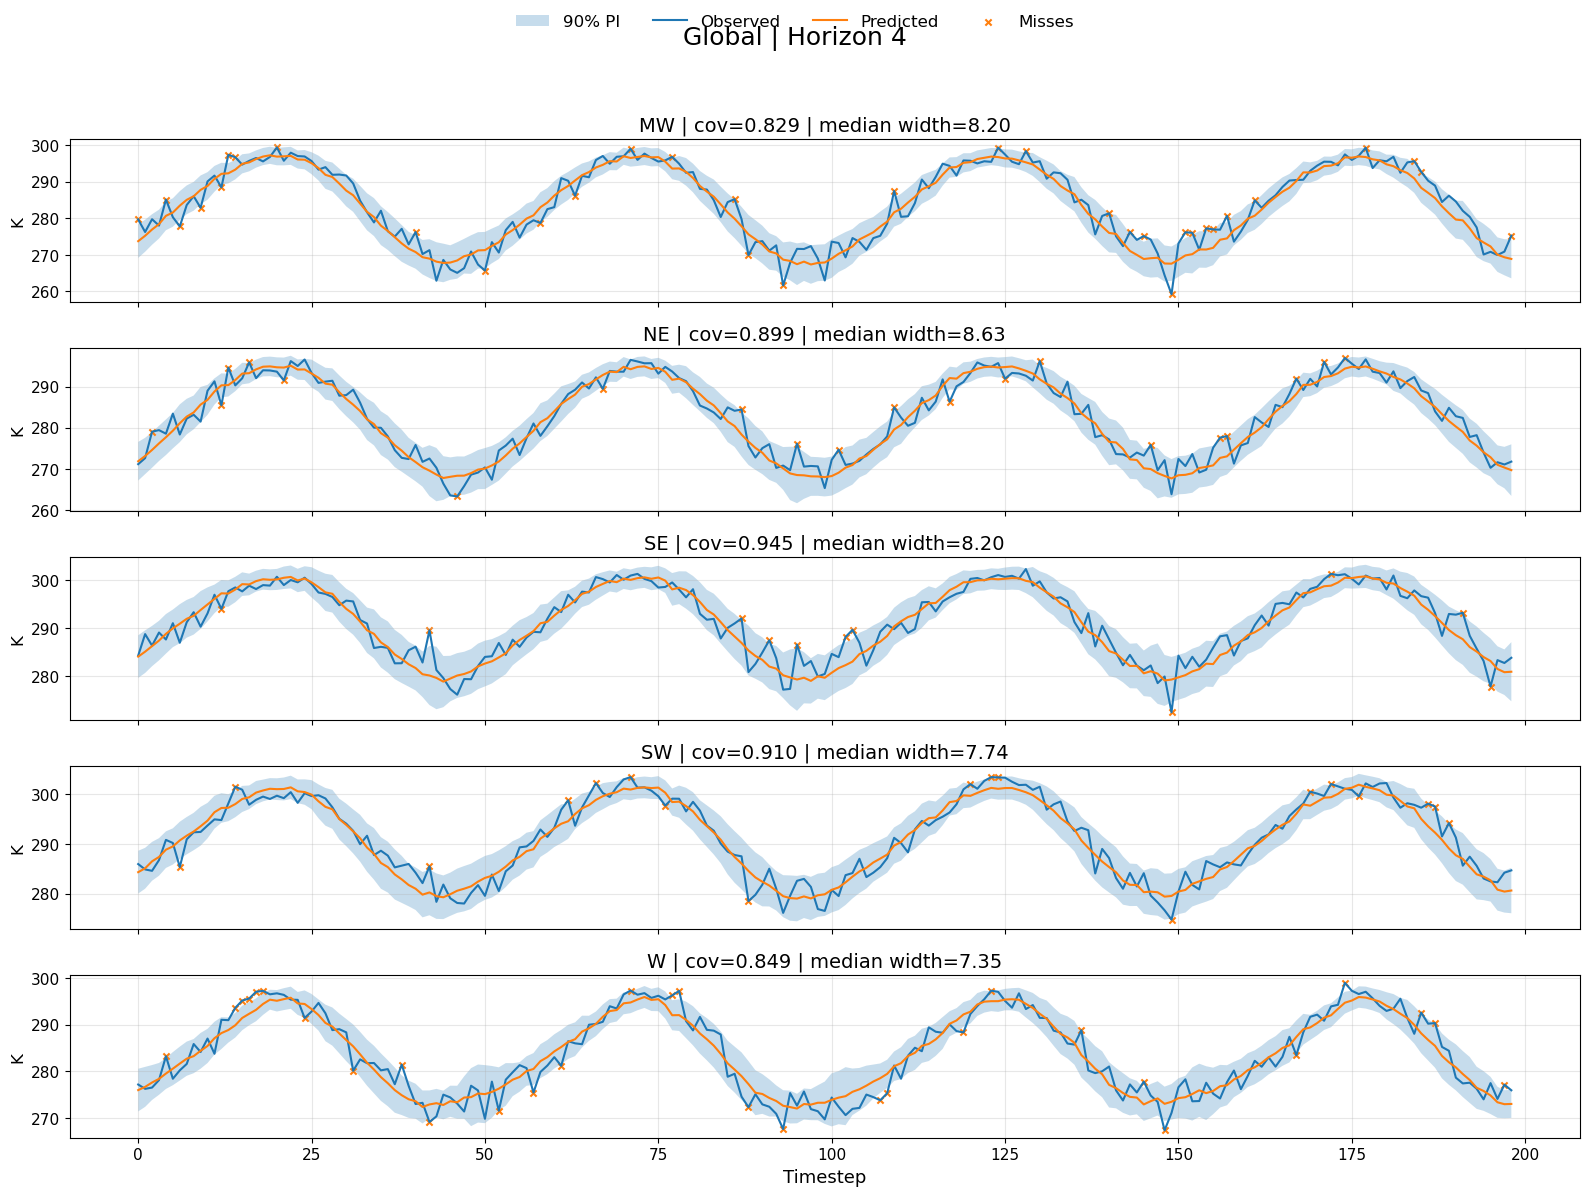

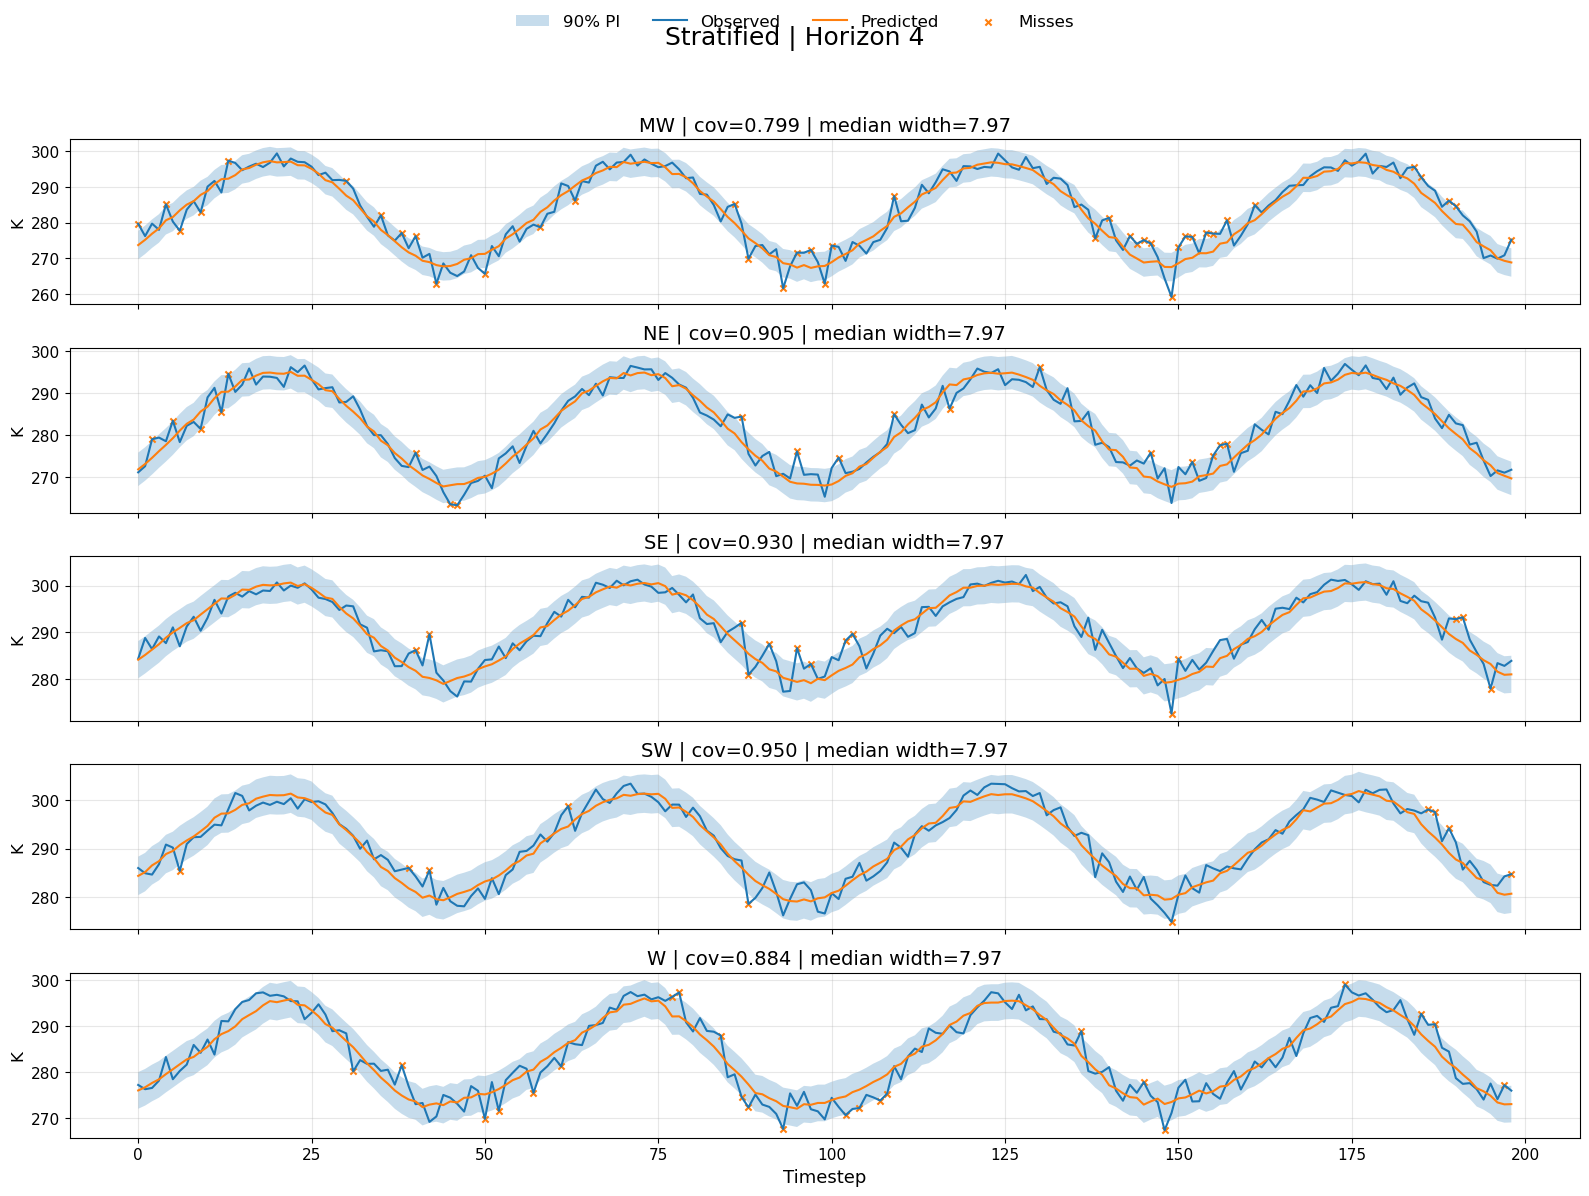

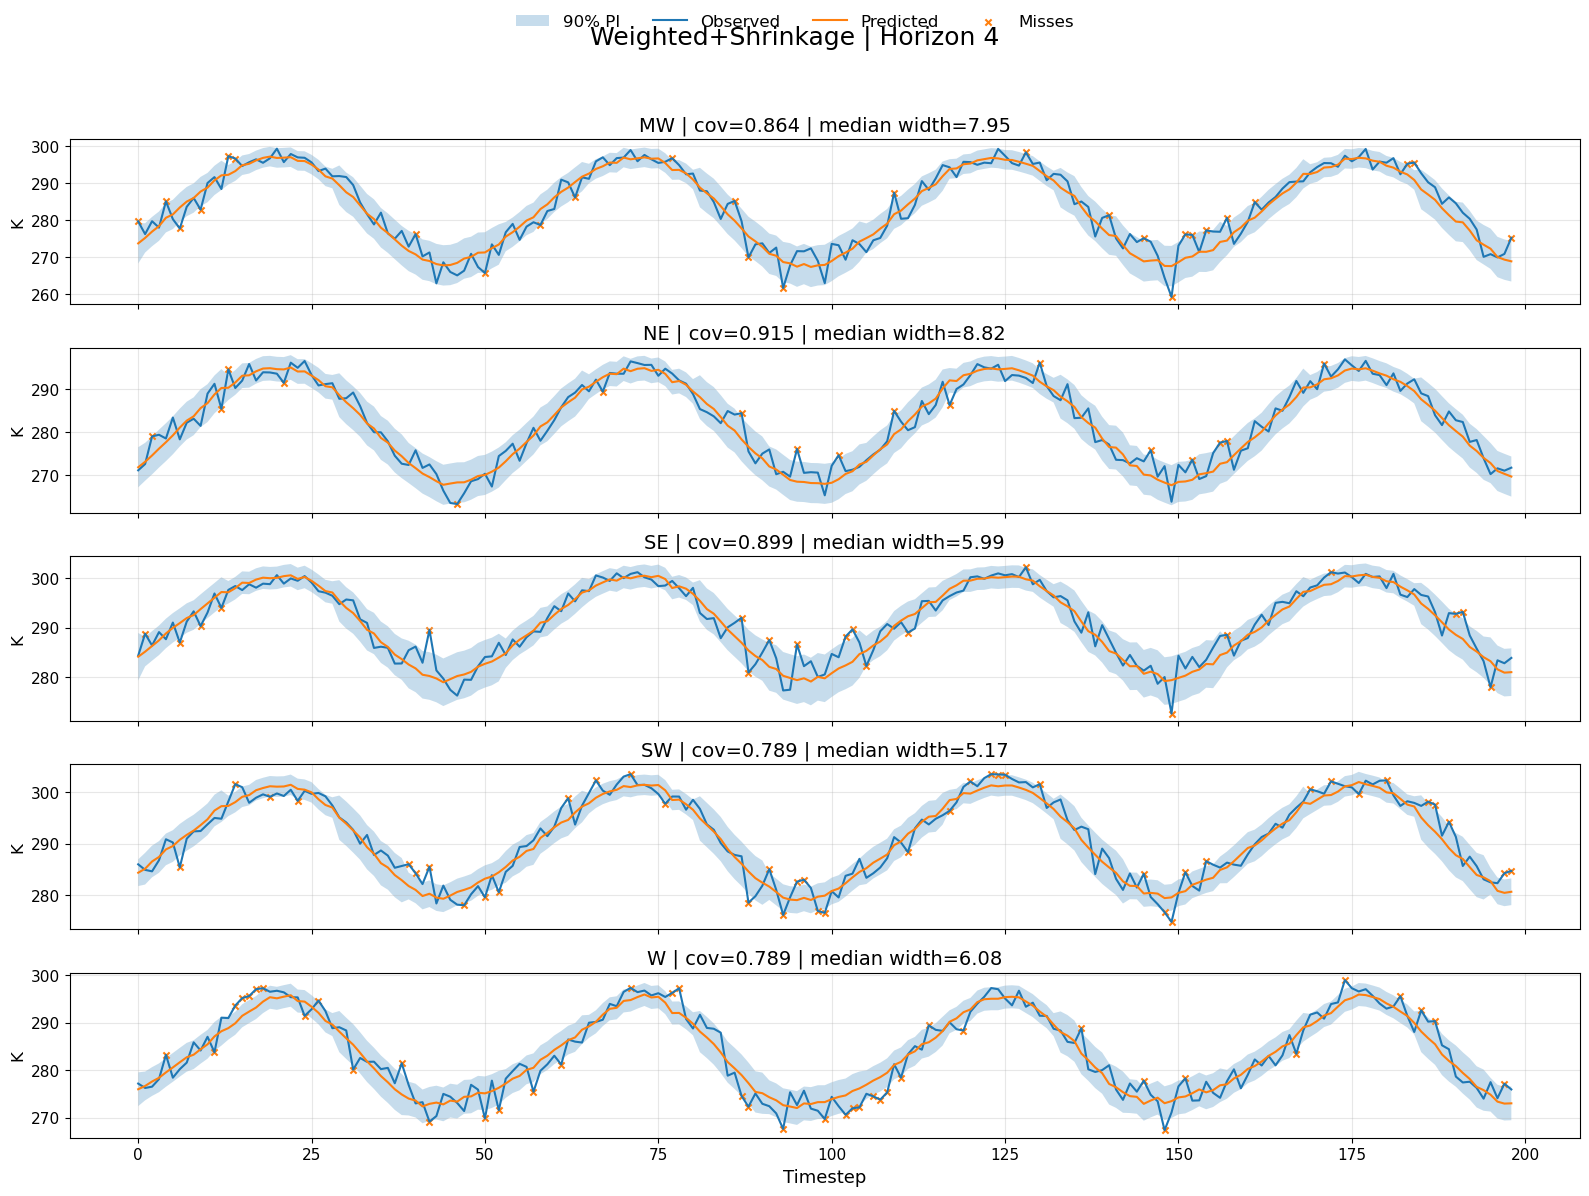

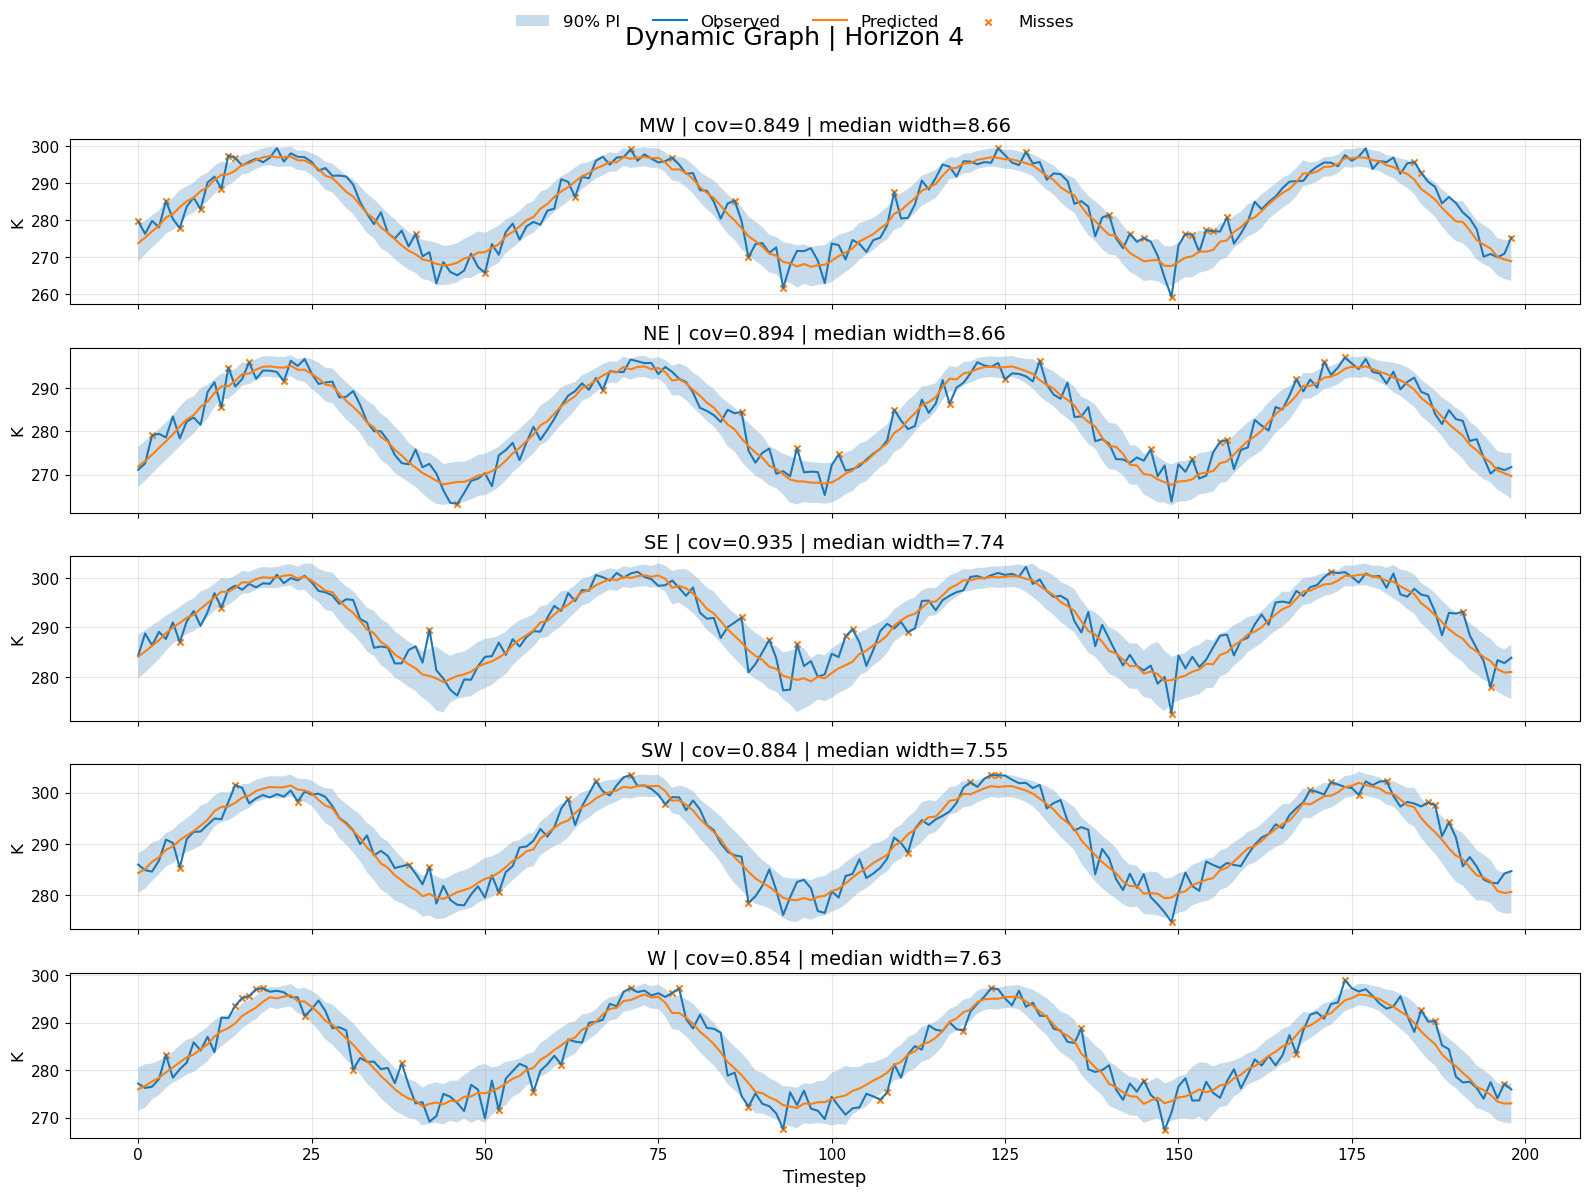

In [26]:
horizon_to_plot = 4
region_order = ["MW", "NE", "SE", "SW", "W"]   # adjust if needed

for method, path in unprocesssed_files.items():
    df = pd.read_csv(path)

    # keep one horizon
    dfh = df[df["horizon"] == horizon_to_plot].copy()

    fig, axes = plt.subplots(len(region_order), 1, figsize=(16, 12), sharex=True)

    if len(region_order) == 1:
        axes = [axes]

    for ax, region in zip(axes, region_order):
        sub = dfh[dfh["Region"] == region].copy()

        # sort by time if forecast_date exists, otherwise by reference_date, otherwise leave as-is
        if "forecast_date" in sub.columns:
            sub = sub.sort_values("forecast_date")
        elif "reference_date" in sub.columns:
            sub = sub.sort_values("reference_date")

        sub = sub.reset_index(drop=True)
        sub["timestep"] = sub.index

        ax.fill_between(
            sub["timestep"],
            sub["lower"],
            sub["upper"],
            alpha=0.25,
            label="90% PI"
        )
        ax.plot(sub["timestep"], sub["y_true"], linewidth=1.5, label="Observed")
        ax.plot(sub["timestep"], sub["y_pred"], linewidth=1.5, label="Predicted")

        # misses
        misses = sub[(sub["y_true"] < sub["lower"]) | (sub["y_true"] > sub["upper"])]
        if len(misses) > 0:
            ax.scatter(
                misses["timestep"],
                misses["y_true"],
                marker="x",
                s=20,
                label="Misses"
            )

        coverage = ((sub["y_true"] >= sub["lower"]) & (sub["y_true"] <= sub["upper"])).mean()
        med_width = (sub["upper"] - sub["lower"]).median()

        ax.set_title(
            f"{region} | cov={coverage:.3f} | median width={med_width:.2f}",
            fontsize=14
        )
        ax.set_ylabel("K", fontsize=12)
        ax.tick_params(axis="both", labelsize=11)
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel("Timestep", fontsize=13)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, fontsize=12)

    fig.suptitle(f"{method} | Horizon {horizon_to_plot}", fontsize=18, y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


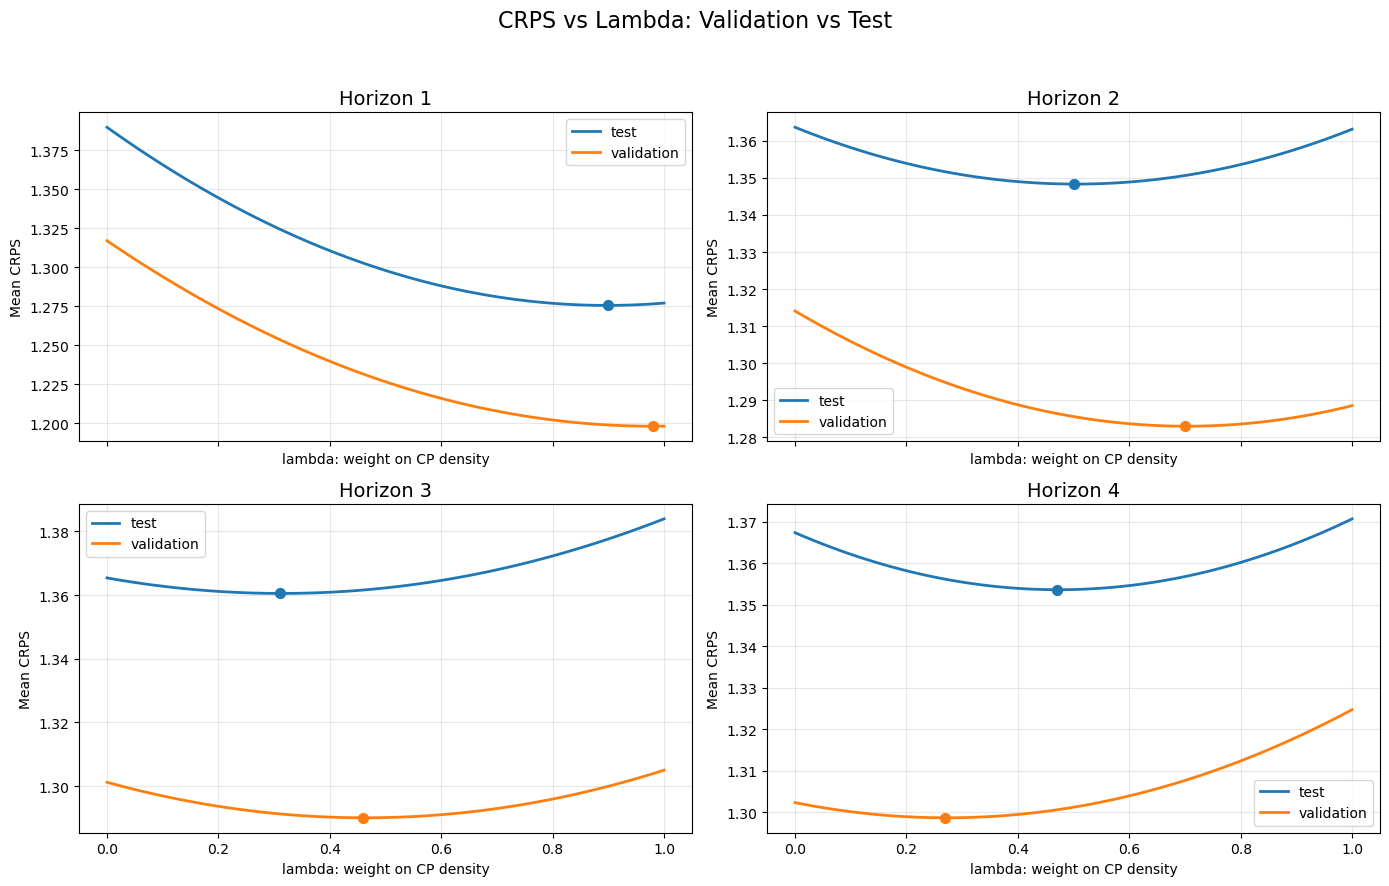

In [16]:
output_dir = PROJECT_ROOT / "outputs" / "tuning" / "clim_mix"
lambda_curves_df = pd.read_csv(output_dir / "lambda_curves.csv")
def plot_lambda_curves(lambda_curves_df):
    horizons = sorted(lambda_curves_df["horizon"].unique())

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=False)
    axes = axes.ravel()

    for ax, h in zip(axes, horizons):
        sub = lambda_curves_df[lambda_curves_df["horizon"] == h]

        for label, grp in sub.groupby("label"):
            ax.plot(
                grp["lambda"],
                grp["mean_crps"],
                linewidth=2,
                label=label,
            )

            # mark minimum
            best = grp.loc[grp["mean_crps"].idxmin()]
            ax.scatter(
                best["lambda"],
                best["mean_crps"],
                s=50,
                zorder=3,
            )

        ax.set_title(f"Horizon {h}", fontsize=14)
        ax.set_xlabel("lambda: weight on CP density")
        ax.set_ylabel("Mean CRPS")
        ax.grid(alpha=0.3)
        ax.legend()

    fig.suptitle("CRPS vs Lambda: Validation vs Test", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_lambda_curves(lambda_curves_df)


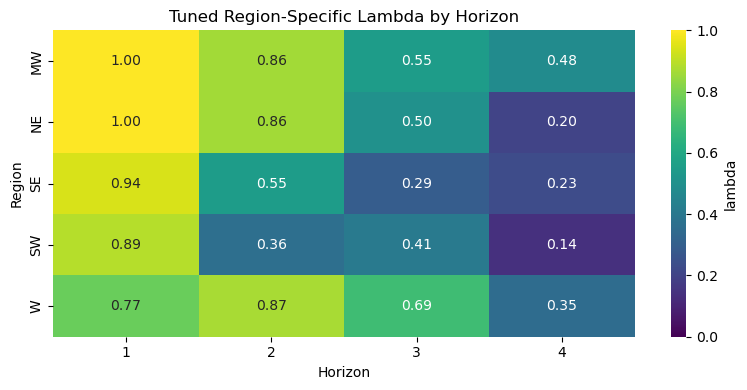

In [17]:
lambda_region_df = pd.read_csv(output_dir / "lambda_region.csv")
import seaborn as sns

def plot_region_lambda_heatmap(lambda_region_df):
    heat = lambda_region_df.pivot(
        index="Region",
        columns="horizon",
        values="lambda",
    )

    plt.figure(figsize=(8, 4))
    sns.heatmap(
        heat,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar_kws={"label": "lambda"},
    )
    plt.title("Tuned Region-Specific Lambda by Horizon")
    plt.xlabel("Horizon")
    plt.ylabel("Region")
    plt.tight_layout()
    plt.show()
plot_region_lambda_heatmap(lambda_region_df)

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_coverage_heatmaps(interval_summary_df):
    region_df = interval_summary_df[
        interval_summary_df["summary_level"] == "Region"
    ].copy()

    methods = list(region_df["method"].unique())

    fig, axes = plt.subplots(
        1,
        len(methods),
        figsize=(5 * len(methods), 4),
        sharey=True,
    )

    if len(methods) == 1:
        axes = [axes]

    vmin = region_df["coverage"].min()
    vmax = region_df["coverage"].max()

    for ax, method in zip(axes, methods):
        sub = region_df[region_df["method"] == method]
        heat = sub.pivot(index="Region", columns="horizon", values="coverage")

        sns.heatmap(
            heat,
            annot=True,
            fmt=".3f",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            ax=ax,
            cbar=(method == methods[-1]),
        )

        ax.set_title(method)
        ax.set_xlabel("Horizon")
        ax.set_ylabel("Region")

    fig.suptitle("90% Interval Coverage by Method, Region, and Horizon", y=1.04)
    plt.tight_layout()
    plt.show()

def plot_width_heatmaps(interval_summary_df, width_col="median_width"):
    region_df = interval_summary_df[
        interval_summary_df["summary_level"] == "Region"
    ].copy()

    methods = list(region_df["method"].unique())

    fig, axes = plt.subplots(
        1,
        len(methods),
        figsize=(5 * len(methods), 4),
        sharey=True,
    )

    if len(methods) == 1:
        axes = [axes]

    vmin = region_df[width_col].min()
    vmax = region_df[width_col].max()

    for ax, method in zip(axes, methods):
        sub = region_df[region_df["method"] == method]
        heat = sub.pivot(index="Region", columns="horizon", values=width_col)

        sns.heatmap(
            heat,
            annot=True,
            fmt=".2f",
            cmap="magma",
            vmin=vmin,
            vmax=vmax,
            ax=ax,
            cbar=(method == methods[-1]),
        )

        ax.set_title(method)
        ax.set_xlabel("Horizon")
        ax.set_ylabel("Region")

    fig.suptitle(f"{width_col.replace('_', ' ').title()} by Method, Region, and Horizon", y=1.04)
    plt.tight_layout()
    plt.show()

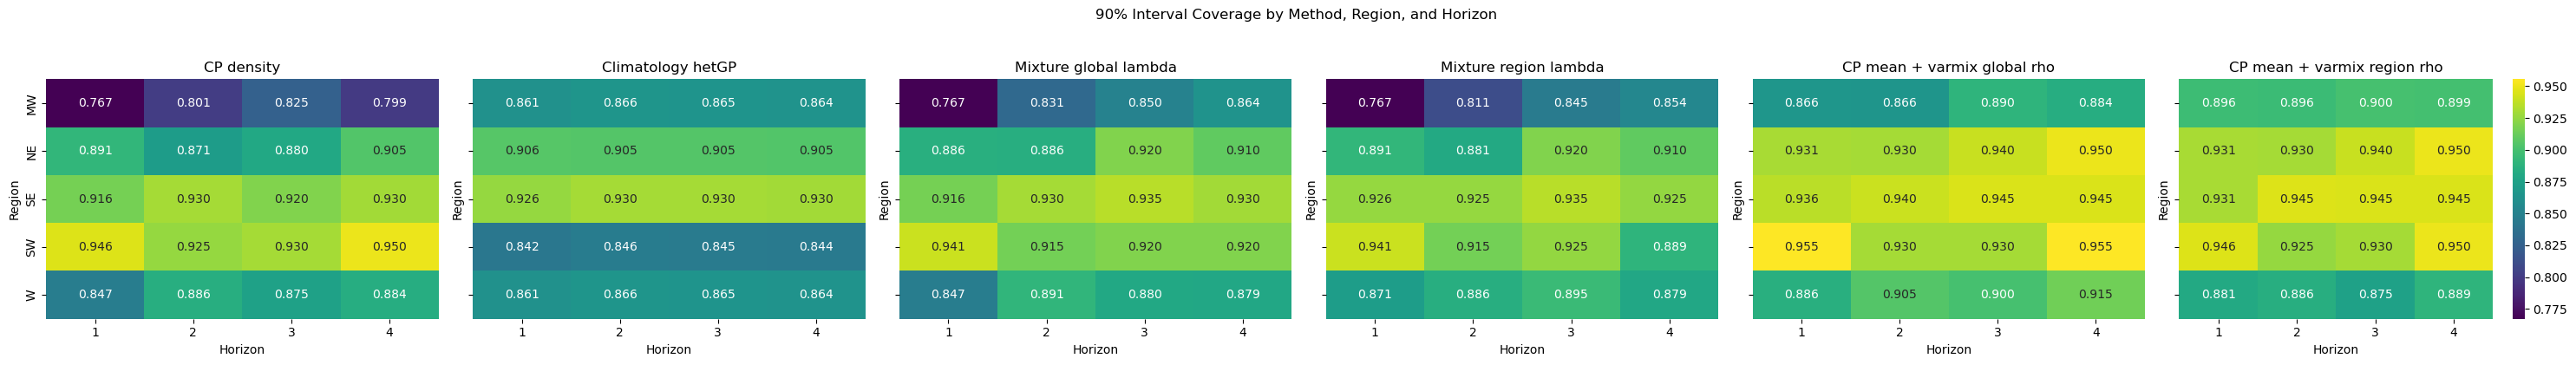

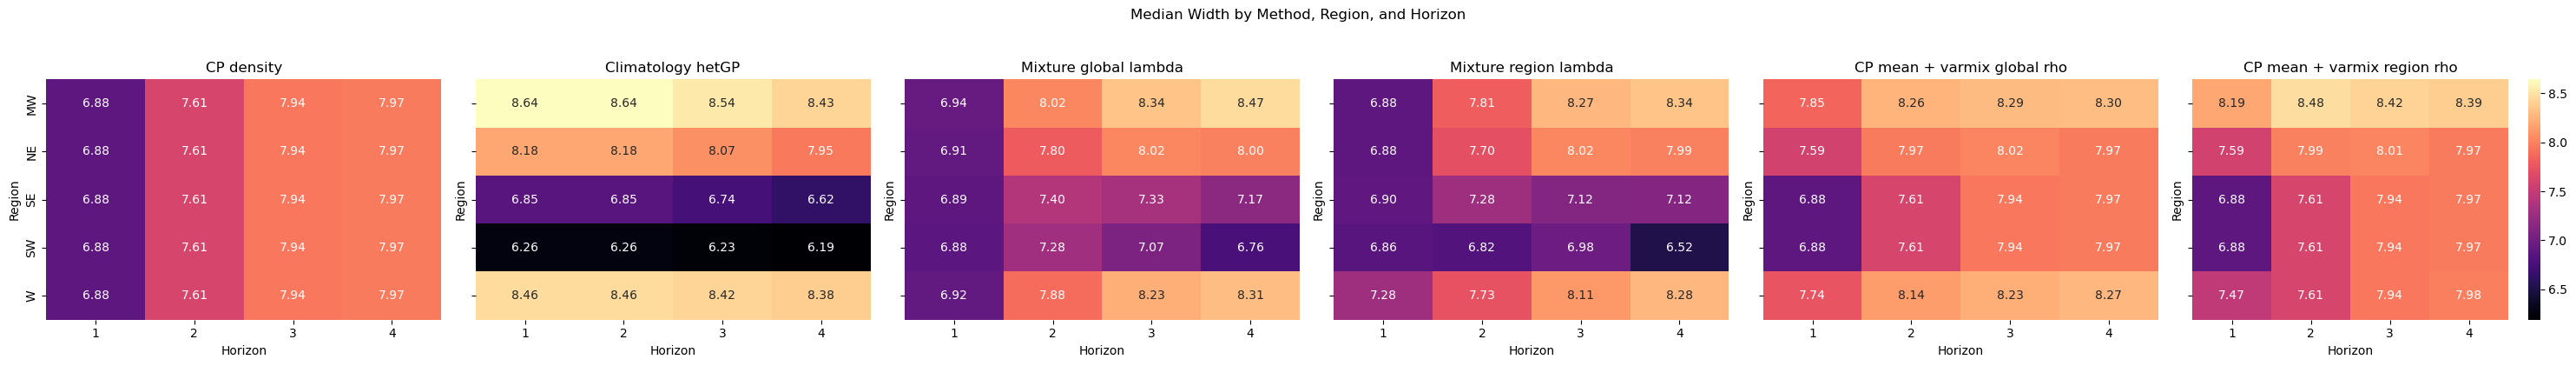

In [5]:
interval_summary_df = pd.read_csv('/home/mfholth/subseasonal/weekly_data/conformal_UQ/conformal_code/outputs/tuning/clim_mix/interval_summary.csv')
plot_coverage_heatmaps(interval_summary_df)
plot_width_heatmaps(interval_summary_df, width_col="median_width")

In [15]:
interval_summary_var = pd.read_csv('/home/mfholth/subseasonal/weekly_data/conformal_UQ/conformal_code/outputs/conformal/processed_results/dynamic_varmix_summary.csv')
interval_summary_infl = pd.read_csv('/home/mfholth/subseasonal/weekly_data/conformal_UQ/conformal_code/outputs/conformal/processed_results/dynamic_varmix_summary_infl.csv')
summary_df = pd.concat((interval_summary_var, interval_summary_infl))
summary_df["summary_level"] = "Region"

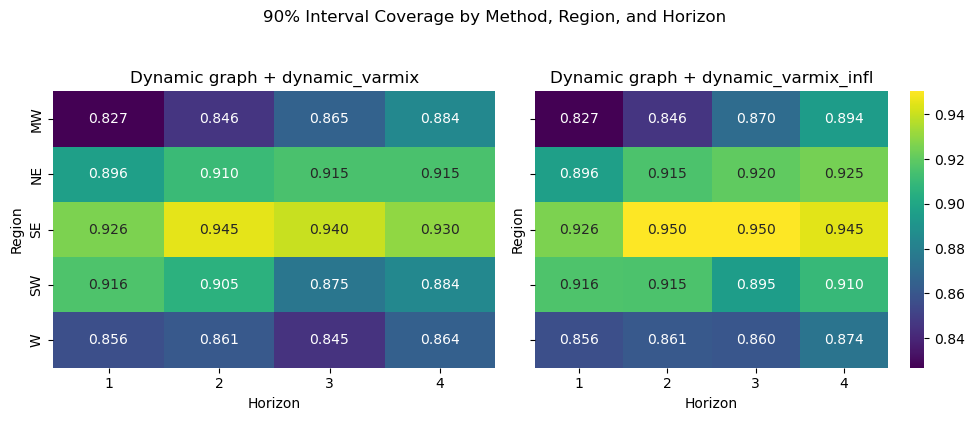

In [16]:
plot_coverage_heatmaps(summary_df)

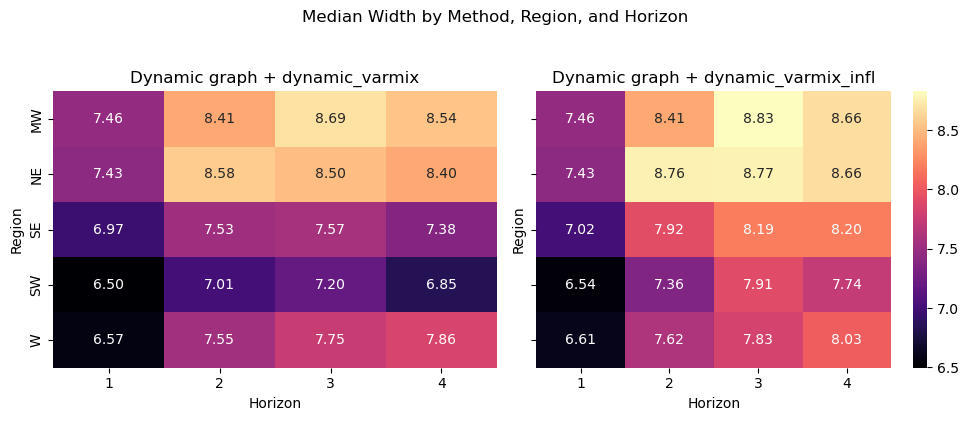

In [17]:
plot_width_heatmaps(summary_df, width_col="median_width")

In [18]:
interval_summary_df = pd.read_csv('/home/mfholth/subseasonal/weekly_data/conformal_UQ/conformal_code/outputs/tuning/clim_mix/interval_summary.csv')
interval_summary_df

,horizon,method,summary_level,Region,Season,coverage,mean_width,median_width,n
0,1,CP density,overall,ALL,ALL,0.873267,6.880579,6.880579,1010
1,1,CP density,Region,MW,ALL,0.767327,6.880579,6.880579,202
2,1,CP density,Region,NE,ALL,0.891089,6.880579,6.880579,202
3,1,CP density,Region,SE,ALL,0.915842,6.880579,6.880579,202
4,1,CP density,Region,SW,ALL,0.945545,6.880579,6.880579,202
...,...,...,...,...,...,...,...,...,...
643,4,CP mean + varmix region rho,Region_Season,SW,Winter,0.914894,7.969003,7.969003,47
644,4,CP mean + varmix region rho,Region_Season,W,Fall,0.800000,8.013412,8.025878,40
645,4,CP mean + varmix region rho,Region_Season,W,Spring,0.916667,7.977454,7.977319,48
646,4,CP mean + varmix region rho,Region_Season,W,Summer,0.953125,7.969003,7.969003,64
